# COM-480 — Milestone 1: Exploratory Data Analysis
## World Happiness Report (2015–2019)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

## 1. Load & unify all years

In [7]:
col_map = {
    'Country or region': 'Country',
    'Overall rank': 'Happiness Rank',
    'Score': 'Happiness Score',
    'Happiness.Rank': 'Happiness Rank',
    'Happiness.Score': 'Happiness Score',
    'Economy..GDP.per.Capita.': 'Economy (GDP per Capita)',
    'Health..Life.Expectancy.': 'Health (Life Expectancy)',
    'Trust..Government.Corruption.': 'Trust (Government Corruption)',
    'GDP per capita': 'Economy (GDP per Capita)',
    'Social support': 'Family',
    'Healthy life expectancy': 'Health (Life Expectancy)',
    'Freedom to make life choices': 'Freedom',
    'Perceptions of corruption': 'Trust (Government Corruption)',
    'Dystopia.Residual': 'Dystopia Residual',
    'Whisker.high': 'Upper Confidence Interval',
    'Whisker.low': 'Lower Confidence Interval',
}

factors = [
    'Economy (GDP per Capita)',
    'Family',
    'Health (Life Expectancy)',
    'Freedom',
    'Trust (Government Corruption)',
    'Generosity',
]

dfs = []
for year in [2015, 2016, 2017, 2018, 2019]:
    df = pd.read_csv("dataset/"+f'{year}.csv')
    df = df.rename(columns=col_map)
    df['Year'] = year
    dfs.append(df)

# Re-attach Region (only in 2015/2016) to all years
region_df = pd.read_csv('dataset/2015.csv')[['Country', 'Region']]
all_data = pd.concat(dfs, ignore_index=True)
all_data = all_data.merge(region_df, on='Country', how='left', suffixes=('', '_mapped'))
all_data['Region'] = all_data['Region'].fillna(all_data['Region_mapped'])
all_data.drop(columns=['Region_mapped'], inplace=True)

print(f'Total records: {len(all_data)}')
print(f'Unique countries: {all_data["Country"].nunique()}')
all_data.head()

Total records: 782
Unique countries: 170


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,Year,Lower Confidence Interval,Upper Confidence Interval
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,2015,NaN,NaN
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,2015,NaN,NaN
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204,2015,NaN,NaN
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531,2015,NaN,NaN
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176,2015,NaN,NaN


## 2. Schema & missing-value audit

In [8]:
for year in [2015, 2016, 2017, 2018, 2019]:
    df = all_data[all_data['Year'] == year]
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    missing_dict = {k: int(v) for k, v in missing.items()}
    print(f'{year}: {df.shape[0]} countries | missing: {missing_dict if missing_dict else "none"}')

2015: 158 countries | missing: {'Lower Confidence Interval': 158, 'Upper Confidence Interval': 158}
2016: 157 countries | missing: {'Standard Error': 157}
2017: 155 countries | missing: {'Region': 6, 'Standard Error': 155}
2018: 156 countries | missing: {'Region': 6, 'Standard Error': 156, 'Trust (Government Corruption)': 1, 'Dystopia Residual': 156, 'Lower Confidence Interval': 156, 'Upper Confidence Interval': 156}
2019: 156 countries | missing: {'Region': 7, 'Standard Error': 156, 'Dystopia Residual': 156, 'Lower Confidence Interval': 156, 'Upper Confidence Interval': 156}


## 3. Global score distribution by year

In [9]:
print(all_data.groupby('Year')['Happiness Score'].describe().round(3))

      count   mean    std    min    25%    50%    75%    max
Year                                                        
2015  158.0  5.376  1.145  2.839  4.526  5.232  6.244  7.587
2016  157.0  5.382  1.142  2.905  4.404  5.314  6.269  7.526
2017  155.0  5.354  1.131  2.693  4.506  5.279  6.102  7.537
2018  156.0  5.376  1.120  2.905  4.454  5.378  6.168  7.632
2019  156.0  5.407  1.113  2.853  4.544  5.380  6.184  7.769


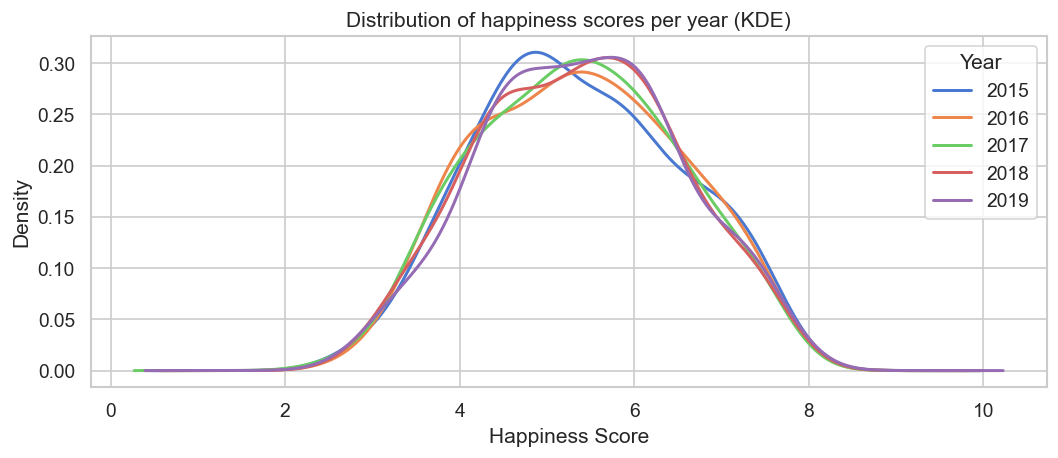

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
for year, grp in all_data.groupby('Year'):
    grp['Happiness Score'].plot.kde(ax=ax, label=str(year), linewidth=1.8)
ax.set_xlabel('Happiness Score')
ax.set_title('Distribution of happiness scores per year (KDE)')
ax.legend(title='Year')
plt.tight_layout()
plt.show()

## 4. Top & bottom countries (average 2015–2019)

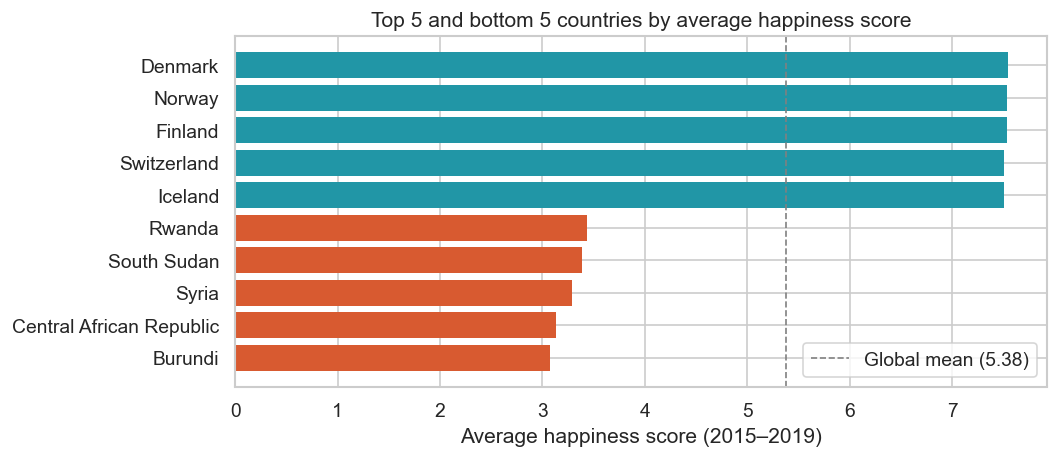

In [11]:
avg_scores = all_data.groupby('Country')['Happiness Score'].mean().sort_values(ascending=False)
top5  = avg_scores.head(5)
bot5  = avg_scores.tail(5)
combined = pd.concat([top5, bot5])

colors = ['#2196A6'] * 5 + ['#D85A30'] * 5

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(combined.index[::-1], combined.values[::-1], color=colors[::-1], edgecolor='none')
ax.set_xlabel('Average happiness score (2015–2019)')
ax.set_title('Top 5 and bottom 5 countries by average happiness score')
ax.axvline(avg_scores.mean(), color='gray', linestyle='--', linewidth=1, label=f'Global mean ({avg_scores.mean():.2f})')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Average happiness by region (2019)

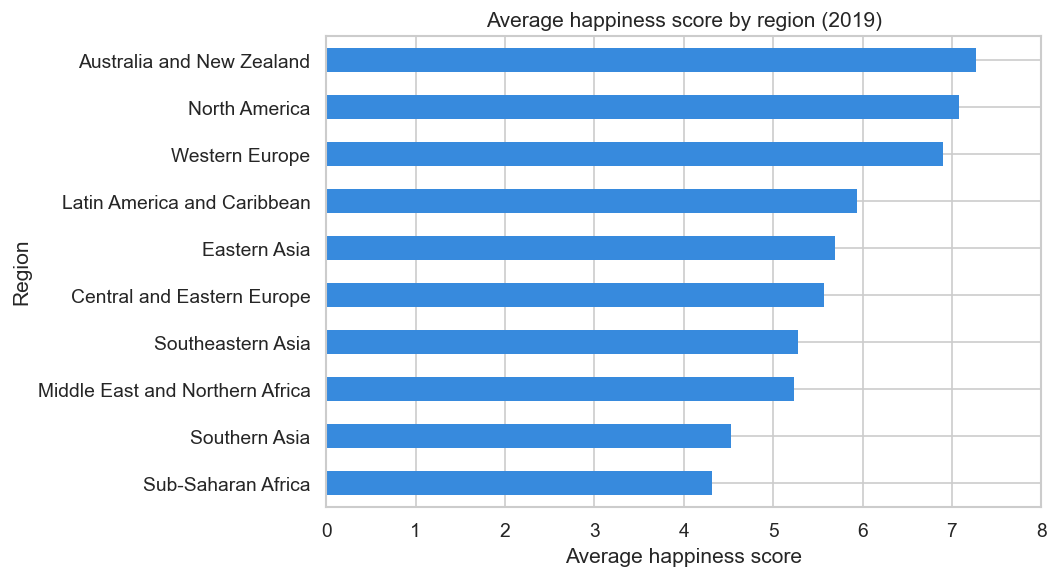

In [12]:
df19 = all_data[all_data['Year'] == 2019]
region_avg = df19.groupby('Region')['Happiness Score'].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
region_avg.plot.barh(ax=ax, color='#378ADD', edgecolor='none')
ax.set_xlabel('Average happiness score')
ax.set_title('Average happiness score by region (2019)')
ax.set_xlim(0, 8)
plt.tight_layout()
plt.show()

## 6. Factor correlations with happiness score (2019)

Economy (GDP per Capita)         0.794
Health (Life Expectancy)         0.780
Family                           0.777
Freedom                          0.567
Trust (Government Corruption)    0.386
Generosity                       0.076
Name: Happiness Score, dtype: float64


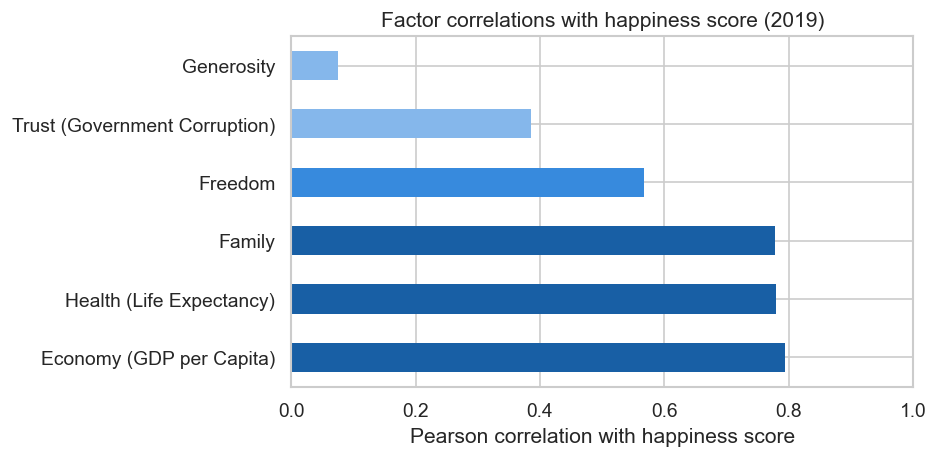

In [13]:
df19_clean = df19[factors + ['Happiness Score']].dropna()
corr = df19_clean.corr()['Happiness Score'].drop('Happiness Score').sort_values(ascending=False)
print(corr.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#185FA5' if v >= 0.7 else '#378ADD' if v >= 0.5 else '#85B7EB' for v in corr]
corr.plot.barh(ax=ax, color=colors, edgecolor='none')
ax.set_xlabel('Pearson correlation with happiness score')
ax.set_title('Factor correlations with happiness score (2019)')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## 7. Correlation heatmap (all factors, 2019)

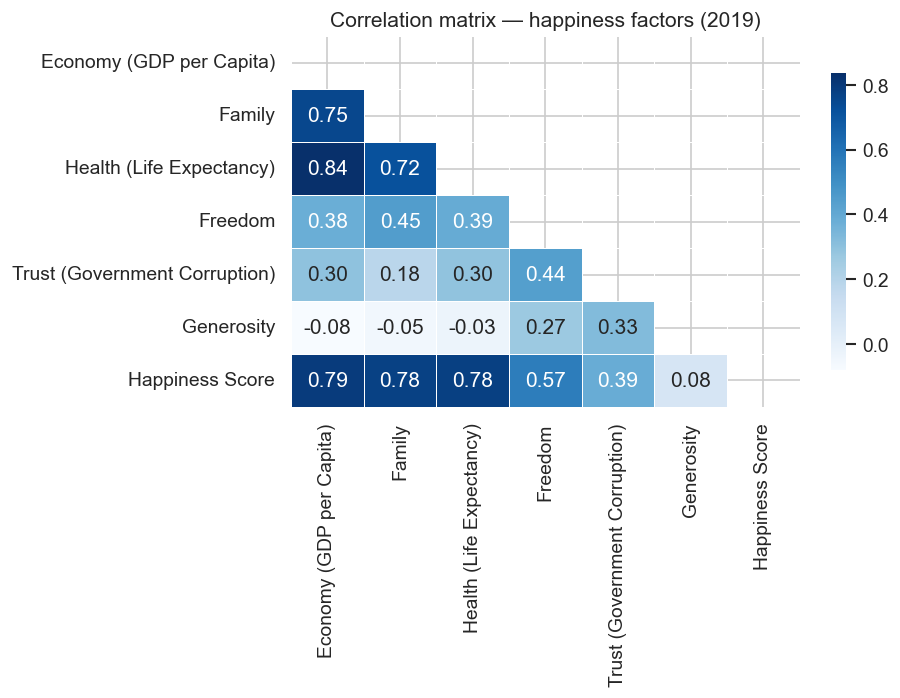

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = df19_clean.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation matrix — happiness factors (2019)')
plt.tight_layout()
plt.show()

## 8. Global average happiness over time

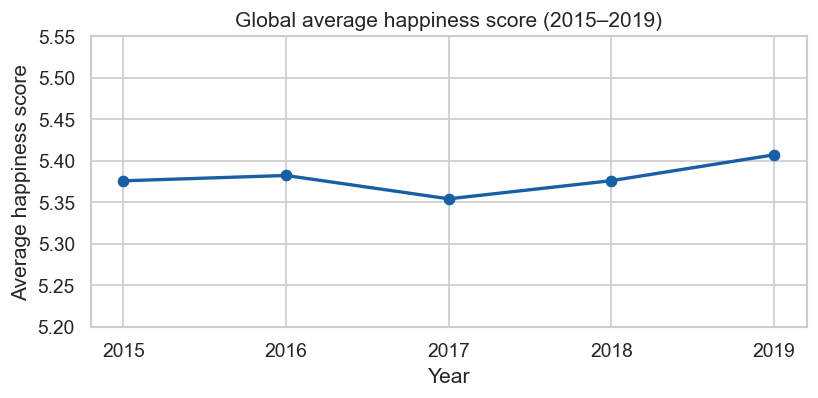

In [15]:
yearly_avg = all_data.groupby('Year')['Happiness Score'].mean()

fig, ax = plt.subplots(figsize=(7, 3.5))
yearly_avg.plot(ax=ax, marker='o', color='#185FA5', linewidth=2)

ax.set_ylim(5.2, 5.55)
ax.set_xlabel('Year')
ax.set_ylabel('Average happiness score')
ax.set_title('Global average happiness score (2015–2019)')

ax.set_xticks(range(2015, 2020)) 

ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.show()

## 9. Most improved & most declined countries (2015 → 2019)

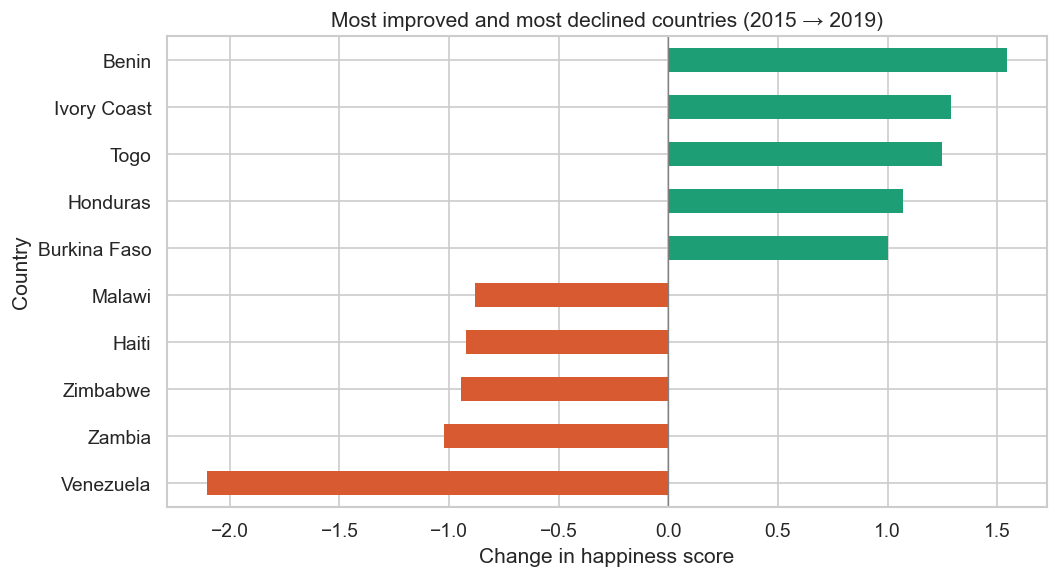

In [16]:
in_all_5 = all_data['Country'].value_counts()
in_all_5 = in_all_5[in_all_5 == 5].index

pivot = (all_data[all_data['Country'].isin(in_all_5)]
         .pivot_table(index='Country', columns='Year', values='Happiness Score'))
pivot['change'] = pivot[2019] - pivot[2015]

top_improved = pivot['change'].sort_values(ascending=False).head(5)
top_declined = pivot['change'].sort_values().head(5)
combined_change = pd.concat([top_improved, top_declined]).sort_values()

colors = ['#D85A30' if v < 0 else '#1D9E75' for v in combined_change]

fig, ax = plt.subplots(figsize=(9, 5))
combined_change.plot.barh(ax=ax, color=colors, edgecolor='none')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Change in happiness score')
ax.set_title('Most improved and most declined countries (2015 → 2019)')
plt.tight_layout()
plt.show()

## 10. GDP vs. happiness scatter (2019)

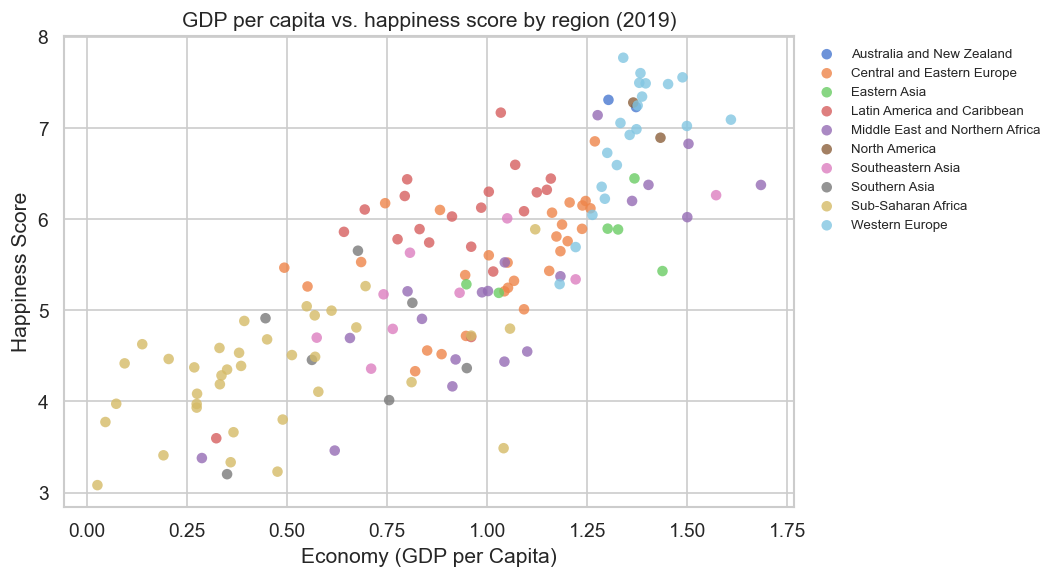

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
for region, grp in df19.groupby('Region'):
    ax.scatter(grp['Economy (GDP per Capita)'], grp['Happiness Score'],
               label=region, s=40, alpha=0.8, edgecolors='none')
ax.set_xlabel('Economy (GDP per Capita)')
ax.set_ylabel('Happiness Score')
ax.set_title('GDP per capita vs. happiness score by region (2019)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, frameon=False)
plt.tight_layout()
plt.show()